## 4. External Variable Inspection

These plots z-score the raw curated predictor columns against CPI YoY for visual inspection only. Use the stationarity-aware lead-lag ([§6](06_lead_lag_correlation)) and Granger ([§7](07_granger_causality)) charts for correlation evidence.

The lagged features screened in the sections that follow are the plain lags only. The squared and interaction terms built for the Elastic Net ([Chapter 4.2](../04_modeling/42_elastic_net)) are modelling features, not raw predictors, so this screen leaves them out.

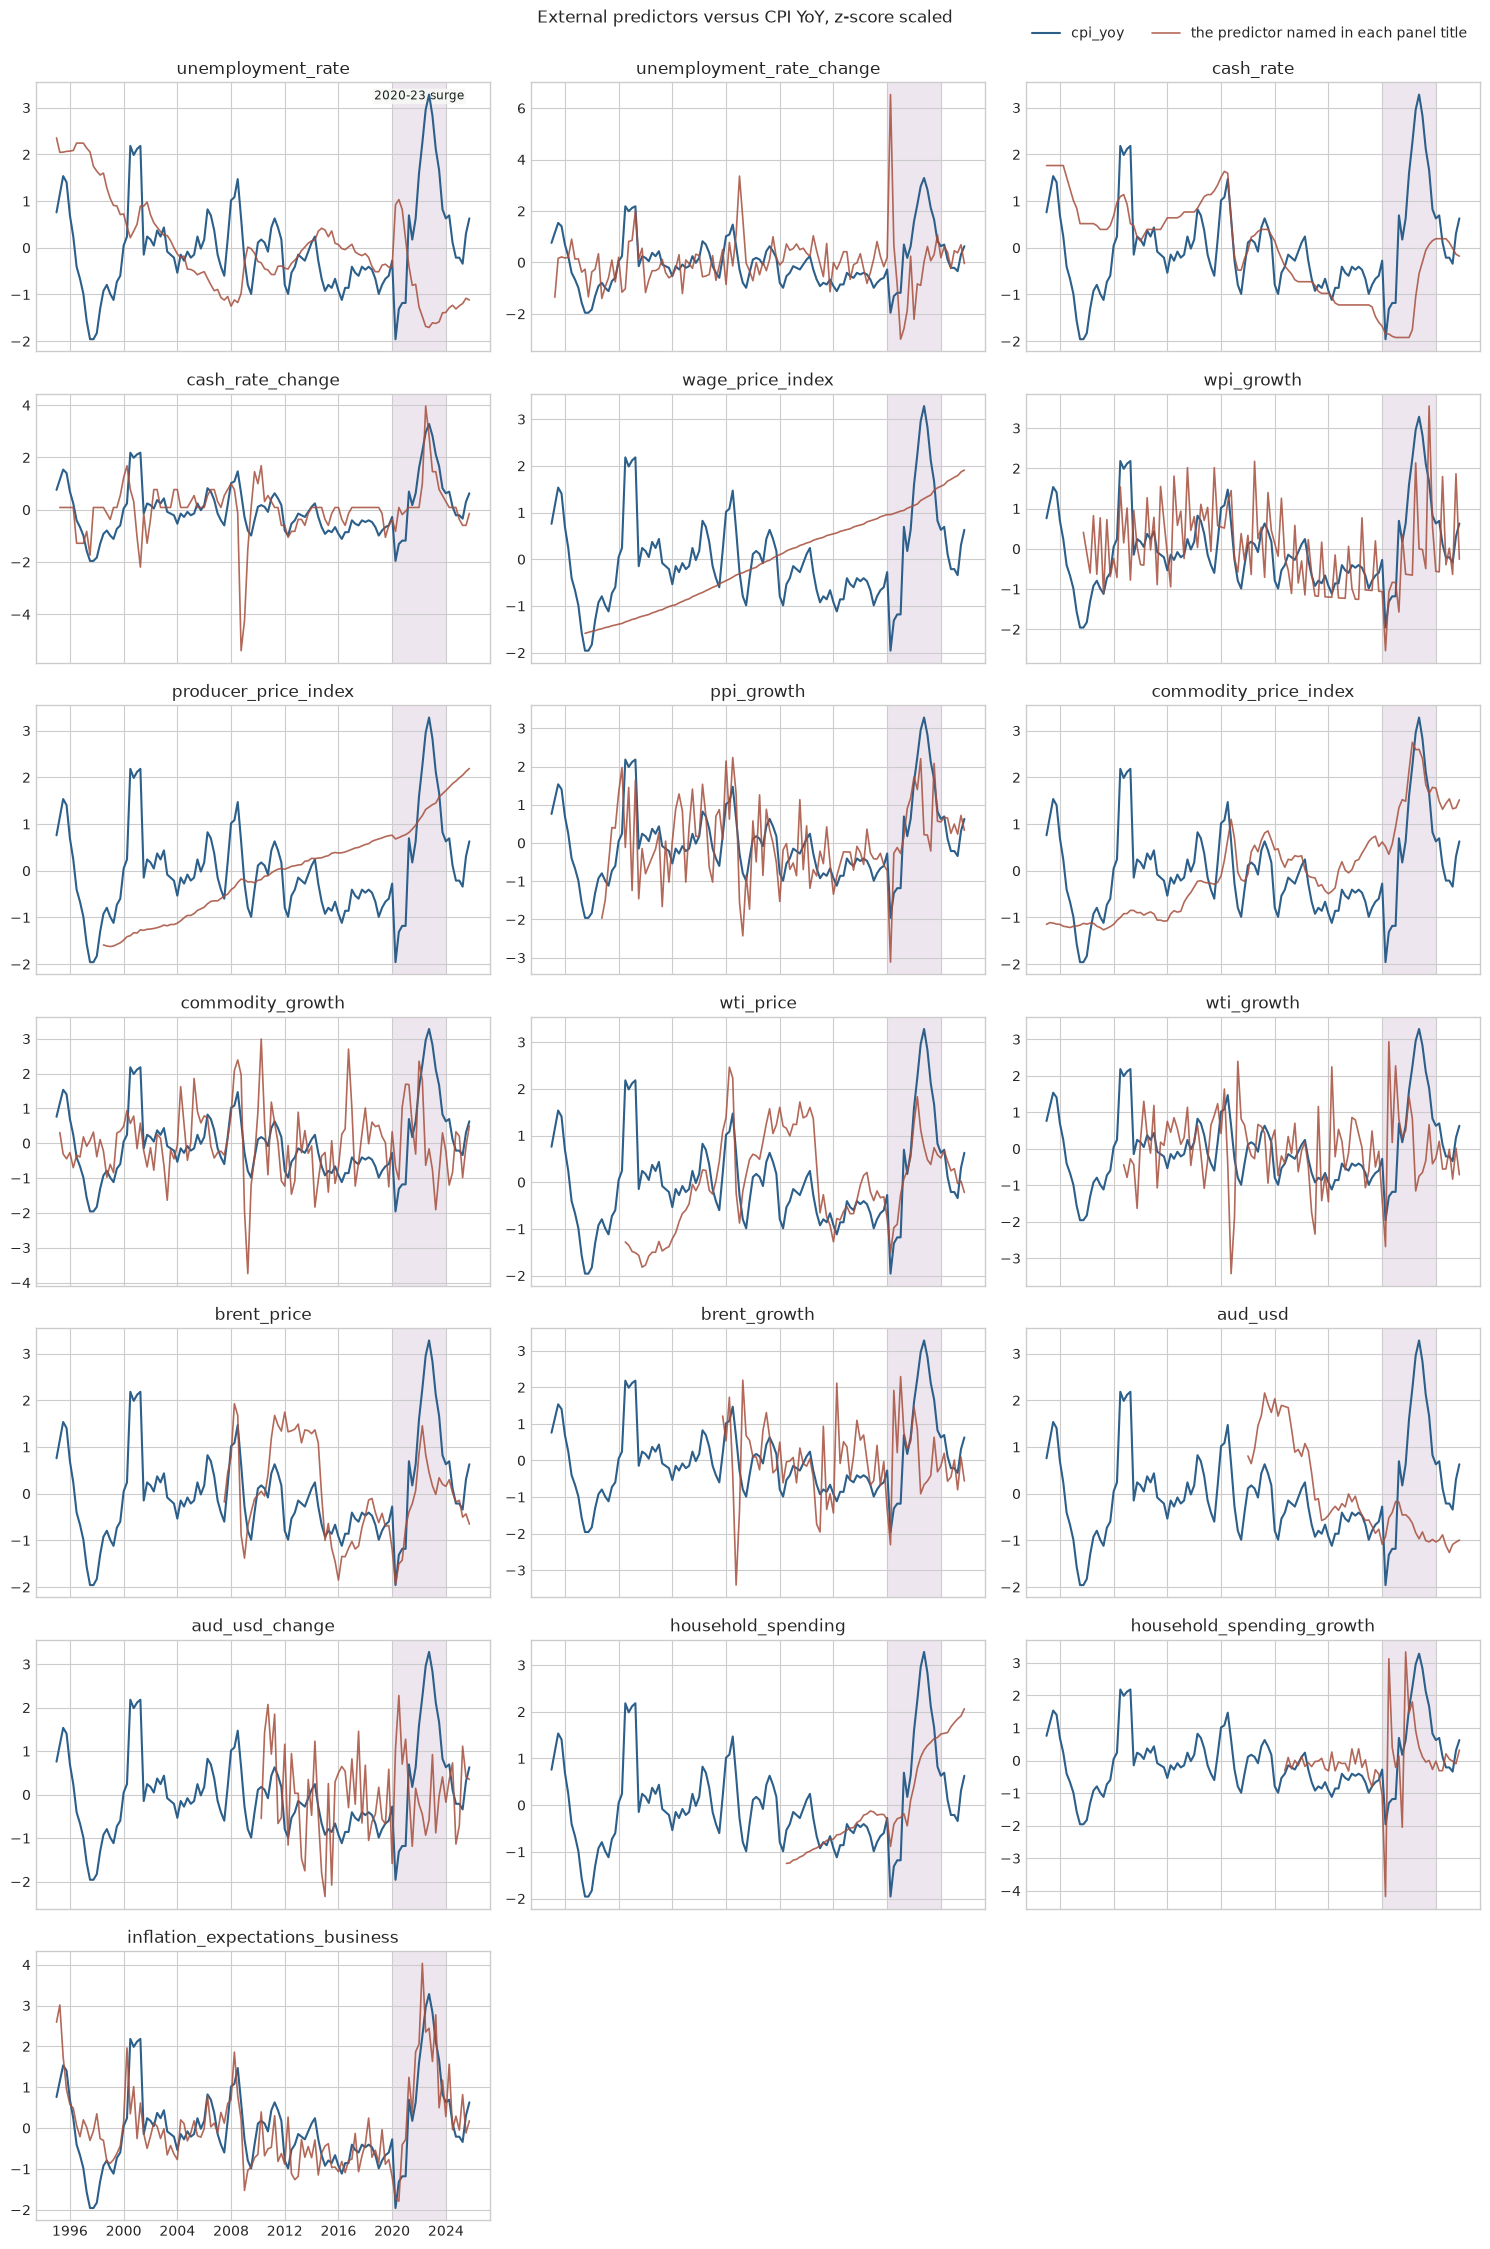

19 external base variables and 21 lagged features are screened in the sections that follow.


In [6]:
cpi_family_exclusion_cols = set(CPI_FAMILY_BASE_COLS + CPI_DERIVED_DIAGNOSTIC_COLS)
EXTERNAL_BASE_COLS = [
    column for column in df_model.columns
    if column not in {'quarter', *cpi_family_exclusion_cols} and '_lag' not in column
]
# Squared and interaction terms are Elastic Net modelling features (Chapter 4.2), not raw external predictors,
# so the EDA screens the plain lags only
engineered_cols = {column for column in df_model.columns if column.endswith('_sq') or '_x_' in column}
EXTERNAL_LAGGED_FEATURES = [
    column for column in df_model.columns
    if '_lag' in column and column not in engineered_cols
    and re.sub(r'_lag\d+$', '', column) not in cpi_family_exclusion_cols
]

def zscore(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors='coerce')
    std = numeric.std(ddof=0)
    if pd.isna(std) or std == 0:
        return numeric * np.nan
    return (numeric - numeric.mean()) / std


def shade_surge(ax, label=False, where="top", alpha=0.14):
    """The 2020-23 COVID and inflation-surge window as one light full-height band: one definition for the whole book.
    label=True names the band in plain text (do that once per figure); `where` is "top" or "bottom"."""
    s, e = pd.Period("2020Q1", "Q").to_timestamp(), pd.Period("2023Q4", "Q").to_timestamp(how="end")
    ax.axvspan(s, e, color="#8a4f8a", alpha=alpha, linewidth=0, zorder=0)
    if label:
        ax.text(s + (e - s) / 2, 0.97 if where == "top" else 0.03, "2020-23 surge", transform=ax.get_xaxis_transform(),
                ha="center", va="top" if where == "top" else "bottom", fontsize=8.5, color="#16211c", zorder=1.6,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="#f7f8f5", edgecolor="none", alpha=0.85))

n_cols = 3
n_rows = int(np.ceil(len(EXTERNAL_BASE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, 3.2 * n_rows)), sharex=True)
axes = np.array(axes).reshape(-1)
for ax, column in zip(axes, EXTERNAL_BASE_COLS):
    ax.plot(df['quarter_start'], zscore(df[TARGET]), label=TARGET, color='#2c5f8a', linewidth=1.5)
    ax.plot(df['quarter_start'], zscore(df[column]), label=column, color='#a64f3c', linewidth=1.2, alpha=0.85)
    ax.set_title(column)
    shade_surge(ax, label=(ax is axes[0]), where="top")
for ax in axes[len(EXTERNAL_BASE_COLS):]:
    ax.axis('off')
fig.suptitle('External predictors versus CPI YoY, z-score scaled', y=1.002)
fig.legend(axes[0].lines[:2], [TARGET, 'the predictor named in each panel title'], loc='upper right',
           ncol=2, frameon=False, fontsize=10, bbox_to_anchor=(0.99, 1.0))
fig.tight_layout()
plt.show()

print(f"{len(EXTERNAL_BASE_COLS)} external base variables and {len(EXTERNAL_LAGGED_FEATURES)} lagged features are screened in the sections that follow.")

**Interpretation.** These charts are a visual pass only. No correlation numbers are
computed here, deliberately, since z-scoring two series on the same axis can *look*
related even when it isn't statistically. What matters is what's tested formally in [§6](06_lead_lag_correlation)
(lead-lag correlation) and [§7](07_granger_causality) (Granger causality) below; this section's job is just to
make sure nothing about the raw external series (a broken unit, an obvious level shift, a
gap) is visually wrong before those formal tests run on them.